# Task 3: Large Liquidation Reaction Filter

This notebook is the handoff for HW 1 Task 3. It summarizes the EDA, filter implementation, train/validation metrics, and Task 2 baseline comparison.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Markdown, display, Image

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
elif not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
    ROOT = ROOT.parent
REPORTS = ROOT / 'reports'
TABLES = REPORTS / 'tables'
FIGURES = REPORTS / 'figures'
pd.set_option('display.max_columns', 100)


## Assignment Logic

The filter removes trades after large liquidations when trade side matches liquidation side. Bybit liquidations are shifted by `+200 ms` before matching.

In [2]:
solution_path = ROOT / 'src' / 'task3_solution.py'
print(solution_path)
print(solution_path.read_text()[:4000])


D:\Python\CMF\HFT_School\Task_3\src\task3_solution.py
from __future__ import annotations

from typing import Any

import numpy as np


BYBIT_DELAY_US = 200_000
HORIZONS = (30, 120, 300)

# Selected after validating both taker-side and maker-side interpretations of
# "trade direction" against q90/q95/q99 liquidation-notional thresholds.
SHORT_LIQ_THRESHOLD = 196_940.36
SHORT_REACTION_WINDOW_SECONDS = 60
LONG_LIQ_THRESHOLD = 38_929.53
LONG_REACTION_WINDOW_SECONDS = 30
LARGE_LIQ_THRESHOLD = LONG_LIQ_THRESHOLD
REACTION_WINDOW_SECONDS = LONG_REACTION_WINDOW_SECONDS
MATCH_MODE = "taker_opposite_liquidation"


def _column(frame: Any, name: str) -> np.ndarray:
    col = frame[name]
    if hasattr(col, "to_numpy"):
        return col.to_numpy()
    if hasattr(col, "to_pandas"):
        return col.to_pandas().to_numpy()
    return np.asarray(col)


def _side_sign(side: np.ndarray) -> np.ndarray:
    side_str = np.asarray(side).astype(str)
    return np.where(np.char.lower(side_str) == "buy", 1, 

## Liquidation Thresholds

In [3]:
thresholds = pd.read_csv(TABLES / 'task3_liq_thresholds.csv')
thresholds


,symbol,exchange,event_count,q90,q95,q99,max_notional
0,all,all,361875,16684.1334,38929.5275,196940.3595,1.548257e+07
1,btcusdt,binance,63660,16820.3480,39357.2719,171672.7320,1.219688e+07
2,btcusdt,bybit,124465,18679.6330,43865.2000,237942.0570,3.439243e+06
3,ethusdt,binance,76634,13563.8116,31441.5122,157971.0000,1.548257e+07
4,ethusdt,bybit,97116,16288.3790,38134.1440,208399.3401,3.031573e+06


## Event Study

Average 30s maker markout from 0 to 300 seconds after large liquidations.

In [4]:
event_study = pd.read_csv(TABLES / 'task3_event_study.csv')
event_study.head(20)


,threshold_label,threshold,relation,bin_start_s,bin_end_s,large_liq_count,trade_count,weight_sum,weighted_pnl_sum,avg_markout_bps
0,q90,16684.13,opposite_direction,0,10,36188,118218523,4.040188e+11,-2.092468e+12,-5.179137
1,q90,16684.13,opposite_direction,10,20,36188,89390559,2.839945e+11,-1.712099e+12,-6.028636
2,q90,16684.13,opposite_direction,20,30,36188,79564445,2.430520e+11,-3.660355e+12,-15.059967
3,q90,16684.13,opposite_direction,30,40,36188,72543387,2.140104e+11,-3.326161e+12,-15.542055
4,q90,16684.13,opposite_direction,40,50,36188,69595780,1.986850e+11,-2.897121e+12,-14.581481
5,q90,16684.13,opposite_direction,50,60,36188,66019682,1.848695e+11,-1.861032e+12,-10.066729
6,q90,16684.13,opposite_direction,60,70,36188,62762496,1.729448e+11,-1.203034e+12,-6.956174
7,q90,16684.13,opposite_direction,70,80,36188,60064941,1.631826e+11,-8.044873e+11,-4.929982
8,q90,16684.13,opposite_direction,80,90,36188,58742424,1.582546e+11,-2.764562e+11,-1.746908
9,q90,16684.13,opposite_direction,90,100,36188,57848569,1.543174e+11,-4.972433e+11,-3.222213


task3_event_study_q90.png


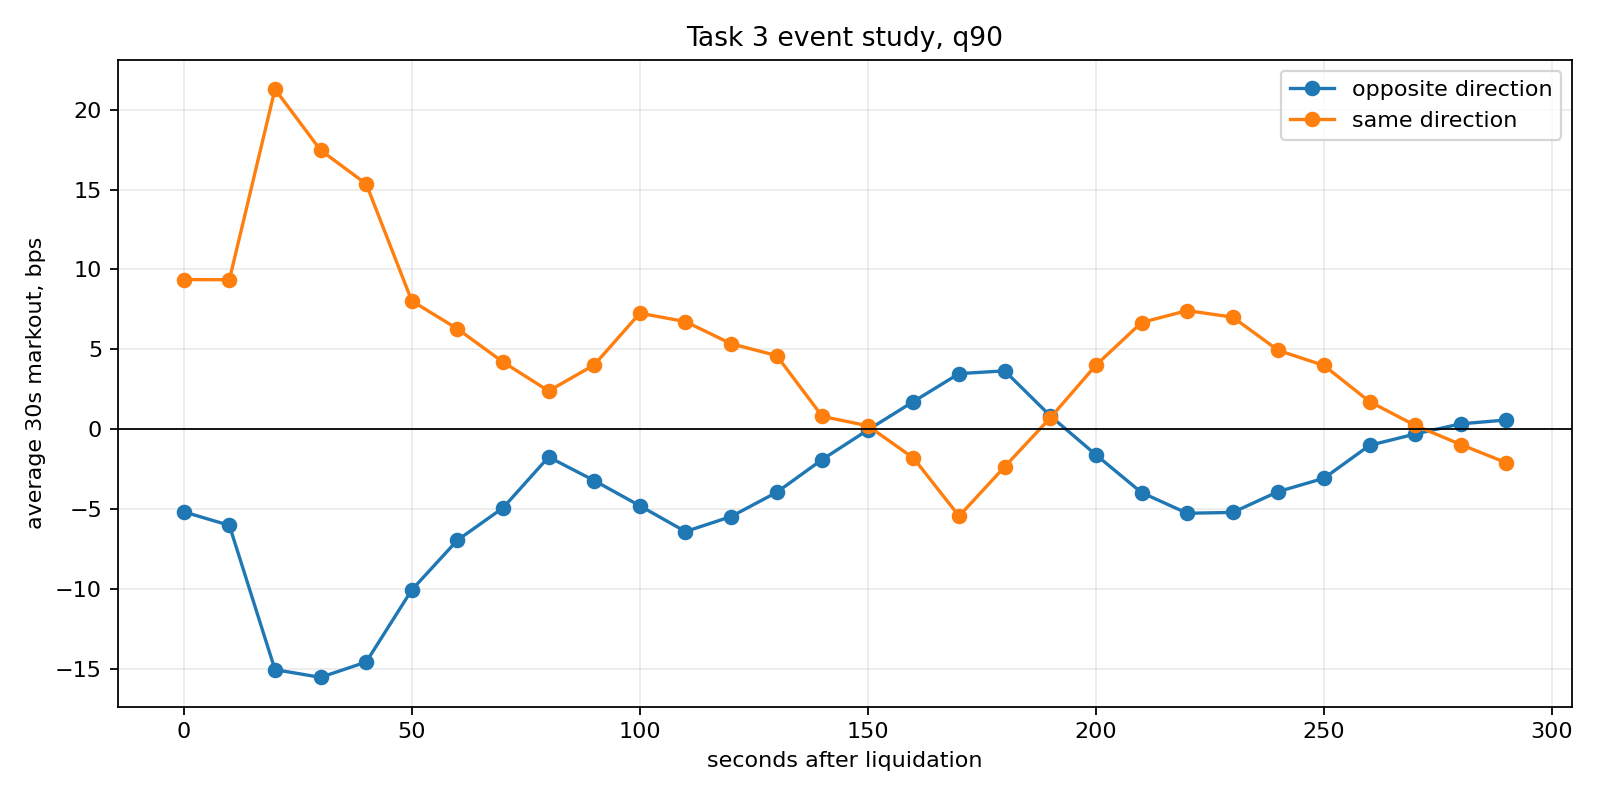

task3_event_study_q95.png


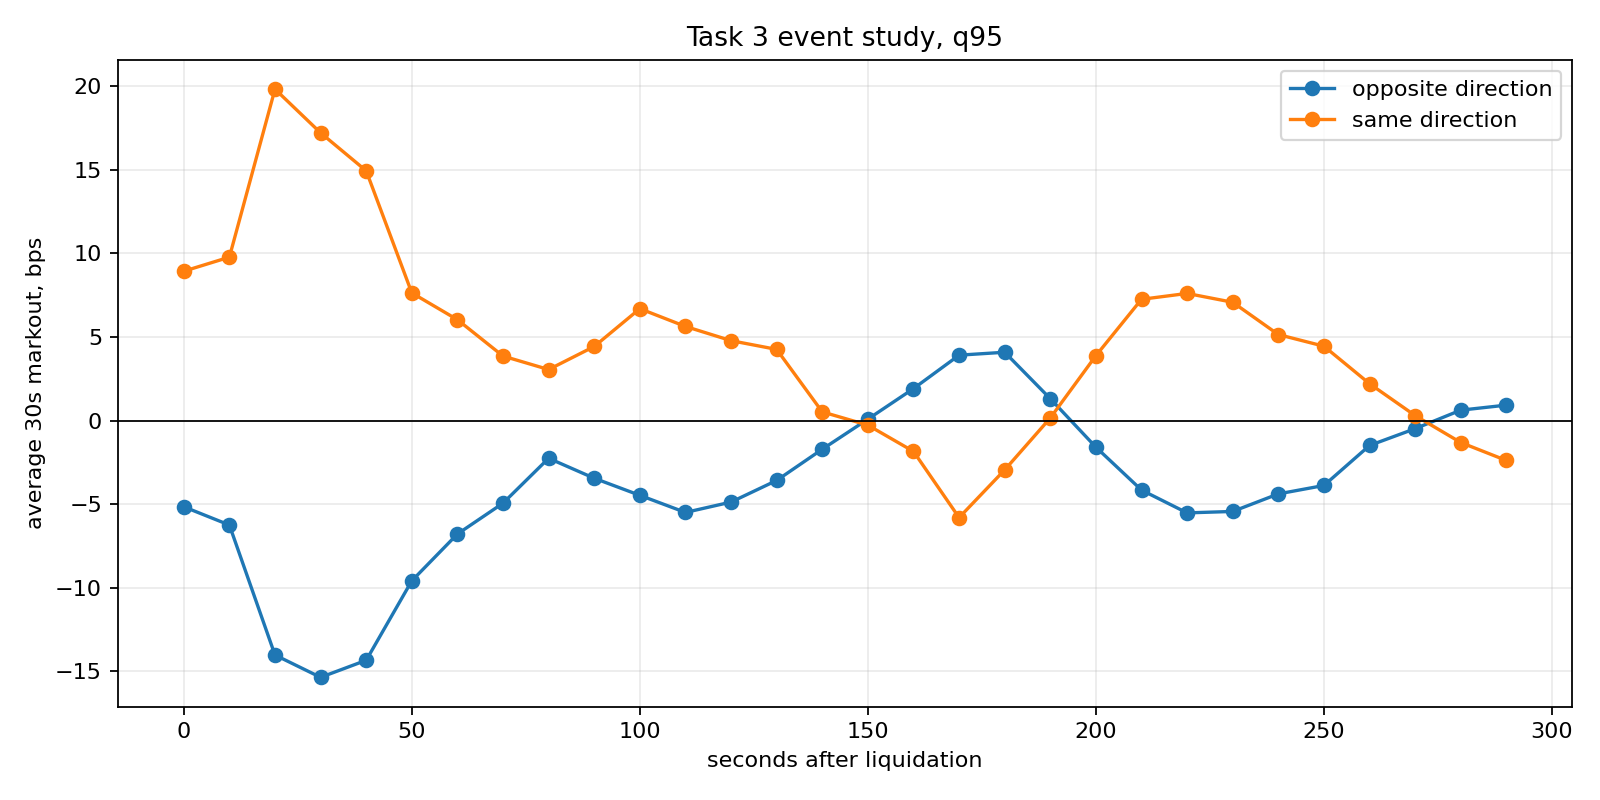

task3_event_study_q99.png


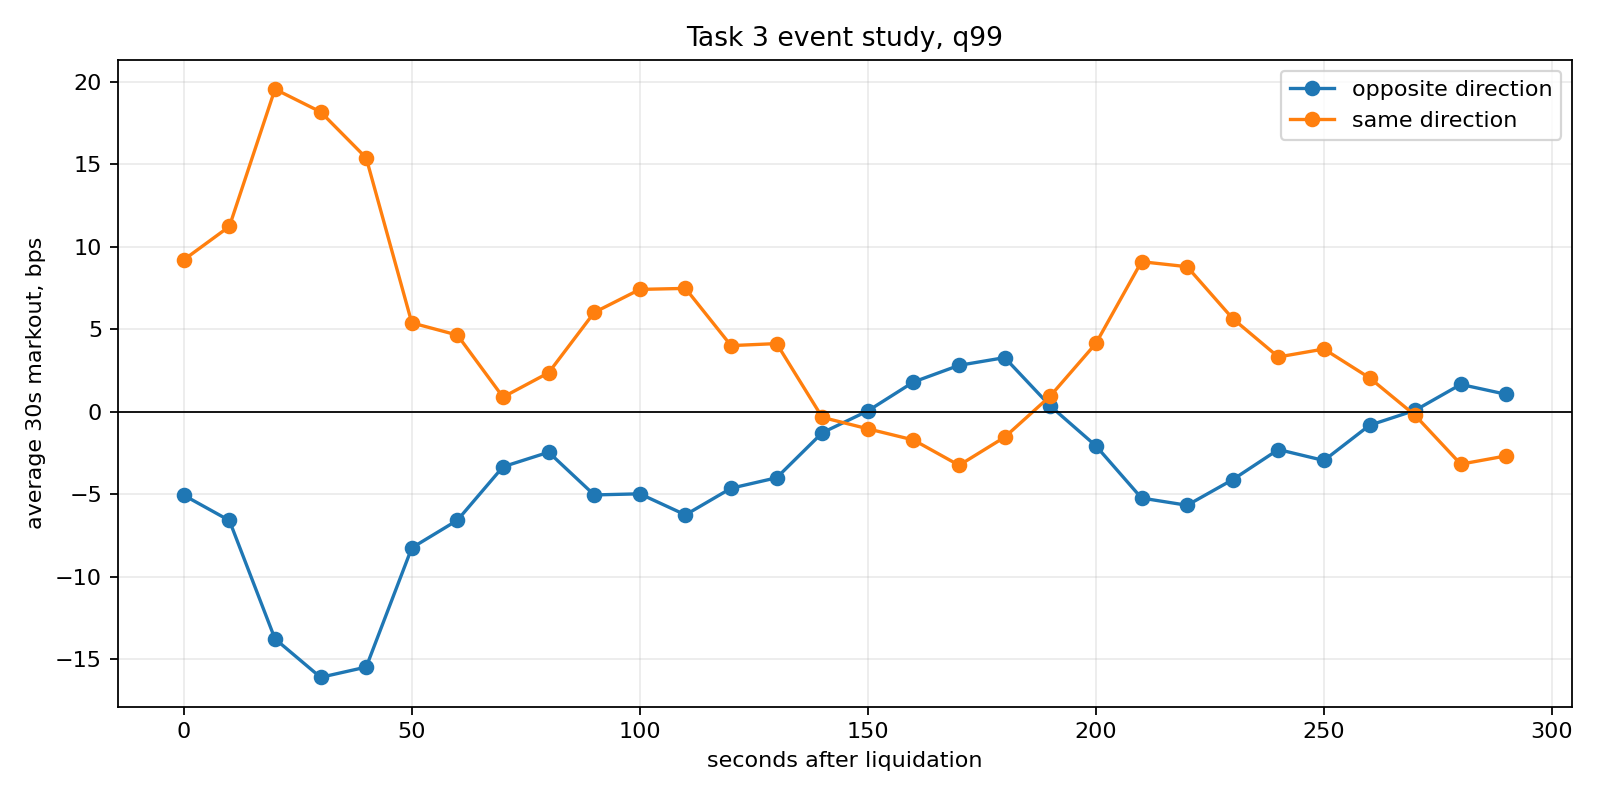

In [5]:
for path in sorted(FIGURES.glob('task3_event_study_*.png')):
    print(path.name)
    display(Image(filename=str(path)))


## Train / Validation Metrics

In [6]:
summary_path = TABLES / 'task3_final_summary_by_split.csv'
if not summary_path.exists():
    summary_path = TABLES / 'task3_full_grid_summary_by_split.csv'
if not summary_path.exists():
    summary_path = TABLES / 'task3_grid_summary_by_split.csv'
summary = pd.read_csv(summary_path)
summary


,strategy,split,horizon_s,days,pnl_all,pnl_kept,pnl_filtered,score,kept_turnover_per_day,constraint_ok,kept_trade_count,filtered_trade_count,all_clipped_turnover,kept_clipped_turnover,filtered_clipped_turnover
0,no_filter,train,30,62,-0.069644,-0.069644,NaN,0.000000,2.206225e+10,True,600370629,0,1.367859e+12,1.367859e+12,0.000000e+00
1,no_filter,train,120,62,0.055228,0.055228,NaN,0.000000,2.206225e+10,True,600370629,0,1.367859e+12,1.367859e+12,0.000000e+00
2,no_filter,train,300,62,0.106595,0.106595,NaN,0.000000,2.206225e+10,True,600370629,0,1.367859e+12,1.367859e+12,0.000000e+00
3,no_filter,validation,30,28,-0.046404,-0.046404,NaN,0.000000,2.716903e+10,True,507412270,0,7.607327e+11,7.607327e+11,0.000000e+00
4,no_filter,validation,120,28,-0.032598,-0.032598,NaN,0.000000,2.716903e+10,True,507412270,0,7.607327e+11,7.607327e+11,0.000000e+00
5,no_filter,validation,300,28,0.024515,0.024515,NaN,0.000000,2.716903e+10,True,507412270,0,7.607327e+11,7.607327e+11,0.000000e+00
6,task3_final_horizon_specific,train,30,62,-0.069644,-0.023063,-1.049745,0.046581,2.106128e+10,True,577730855,22639774,1.367859e+12,1.305799e+12,6.205992e+10
7,task3_final_horizon_specific,train,120,62,0.055228,0.174961,-1.500202,0.119733,2.048534e+10,True,563768962,36601667,1.367859e+12,1.270091e+12,9.776824e+10
8,task3_final_horizon_specific,train,300,62,0.106595,0.171888,-0.741612,0.065293,2.048534e+10,True,563768962,36601667,1.367859e+12,1.270091e+12,9.776824e+10
9,task3_final_horizon_specific,validation,30,28,-0.046404,-0.009730,-0.870818,0.036674,2.601189e+10,True,490719190,16693080,7.607327e+11,7.283329e+11,3.239982e+10


## Robustness Checks

Final strategy stability by split, horizon, symbol, and daily score distribution.

In [7]:
robustness_path = TABLES / 'task3_final_robustness.csv'
symbol_path = TABLES / 'task3_final_symbol_summary.csv'
if robustness_path.exists():
    robustness = pd.read_csv(robustness_path)
    display(robustness)
else:
    print('Robustness table is not available yet.')

if symbol_path.exists():
    symbol_summary = pd.read_csv(symbol_path)
    display(symbol_summary)
else:
    print('Symbol summary table is not available yet.')


,split,horizon_s,days,pnl_all,pnl_kept,pnl_filtered,score,kept_turnover_per_day,positive_symbol_days,symbol_days,positive_symbol_day_rate,daily_score_mean,daily_score_median,daily_score_p10,daily_score_p90
0,train,30,62.0,-0.069644,-0.023063,-1.049745,0.046581,2.106128e+10,83.0,124.0,0.669355,0.042582,0.022440,-0.088669,0.235042
1,train,120,62.0,0.055228,0.174961,-1.500202,0.119733,2.048534e+10,84.0,124.0,0.677419,0.113724,0.057547,-0.258720,0.486522
2,train,300,62.0,0.106595,0.171888,-0.741612,0.065293,2.048534e+10,82.0,124.0,0.661290,0.104941,0.156068,-0.898617,0.847691
3,validation,30,28.0,-0.046404,-0.009730,-0.870818,0.036674,2.601189e+10,36.0,56.0,0.642857,0.016584,0.042919,-0.111619,0.196734
4,validation,120,28.0,-0.032598,0.079595,-1.336677,0.112193,2.501678e+10,34.0,56.0,0.607143,0.069738,0.056227,-0.358331,0.556846
5,validation,300,28.0,0.024515,0.228977,-2.352067,0.204462,2.501678e+10,37.0,56.0,0.660714,0.192192,0.148309,-0.619772,1.194031


,split,symbol,horizon_s,days,pnl_all,pnl_kept,pnl_filtered,score,kept_turnover_per_day,positive_symbol_days,symbol_days,positive_symbol_day_rate,daily_score_mean,daily_score_median,daily_score_p10,daily_score_p90
0,train,btcusdt,30,62.0,-0.104926,-0.067995,-0.883838,0.036931,1.064360e+10,39.0,62.0,0.629032,0.032713,0.013253,-0.088128,0.144363
1,train,btcusdt,120,62.0,0.003930,0.033378,-0.388577,0.029448,1.037023e+10,37.0,62.0,0.596774,0.046690,0.027780,-0.260320,0.347183
2,train,btcusdt,300,62.0,0.034091,0.028810,0.104484,-0.005281,1.037023e+10,40.0,62.0,0.645161,0.043731,0.149100,-0.836922,0.747209
3,train,ethusdt,30,62.0,-0.033604,0.022843,-1.218435,0.056448,1.041768e+10,44.0,62.0,0.709677,0.052451,0.048447,-0.083519,0.244271
4,train,ethusdt,120,62.0,0.107628,0.320116,-2.582786,0.212488,1.011511e+10,47.0,62.0,0.758065,0.180757,0.110103,-0.242866,0.582872
5,train,ethusdt,300,62.0,0.180655,0.318574,-1.565603,0.137919,1.011511e+10,42.0,62.0,0.677419,0.166152,0.175155,-0.928870,1.237049
6,validation,btcusdt,30,28.0,-0.187696,-0.125963,-1.452558,0.061733,1.397211e+10,17.0,28.0,0.607143,0.035159,0.039510,-0.109267,0.139817
7,validation,btcusdt,120,28.0,-0.174253,-0.096948,-1.042959,0.077305,1.345656e+10,17.0,28.0,0.607143,0.038485,0.038288,-0.339030,0.411197
8,validation,btcusdt,300,28.0,-0.155565,0.053934,-2.509782,0.209499,1.345656e+10,20.0,28.0,0.714286,0.182935,0.149604,-0.717854,1.099423
9,validation,ethusdt,30,28.0,0.119038,0.125158,-0.036014,0.006120,1.203978e+10,19.0,28.0,0.678571,-0.001991,0.061413,-0.104163,0.205389


## Experiment Log

Additional variants were saved instead of overwritten.

In [8]:
experiment_log = REPORTS / 'experiments' / 'experiment_log.md'
if experiment_log.exists():
    display(Markdown(experiment_log.read_text()))
else:
    print('Experiment log is not available yet.')


# Task 3 Experiment Log

This log records the main research branches tried for the large-liquidation reaction filter.

## Final Candidate

Final submitted rule: `task3_final_horizon_specific`.

| horizon | rule | validation score | decision |
|---:|---|---:|---|
| 30s | maker-side liquidation filter, global q99 notional, 60s window | 0.036674 | keep |
| 120s | maker-side liquidation filter, global q95 notional, 30s window | 0.112193 | keep |
| 300s | maker-side liquidation filter, global q95 notional, 30s window | 0.204462 | keep |

The final rule is chosen for positive train and validation scores at all three horizons, high kept turnover, and simple interpretation.

## Experiments

### exp00_current_final

Path: `reports/experiments/exp00_current_final/`

Snapshot of the first stable Task 3 solution, report, figures, and key tables.

### exp01_advanced_week

Path: `reports/experiments/exp01_advanced_week/`

Tested broader source/threshold/window choices on a quick train-week screen:

- sources: both, Binance-only, Bybit-only;
- quantiles: q85, q90, q95, q97, q99;
- windows: 10, 20, 30, 45, 60, 90, 120 seconds.

Useful finding: very short windows could improve 30s on a week sample, and Binance q99 looked interesting for 300s. Not promoted directly because week-only results were unstable for 120s/300s.

### exp02_full_binance_q99

Path: `reports/experiments/exp02_full_binance_q99/`

Full-period check of the promising Binance-only q99 family.

Best validation scores:

| horizon | best Binance q99 variant | validation score |
|---:|---|---:|
| 30s | `adv_binance_q99_win45` | 0.011651 |
| 120s | `adv_binance_q99_win60` | 0.049008 |
| 300s | `adv_binance_q99_win90` | 0.073833 |

Decision: not promoted. It is positive, but weaker than final horizon-specific rule.

### exp03_symbol_week

Path: `reports/experiments/exp03_symbol_week/`

Tested symbol-specific liquidation thresholds for BTC and ETH.

Decision: not promoted. Symbol thresholds improved some short-horizon week cases, but were weak or negative for 120s and 300s in the quick screen.

### exp04_guard_week

Path: `reports/experiments/exp04_guard_week/`

Tested return-guard overlays on top of q95/q99 liquidation filters.

Useful finding: some guards improved 30s on the quick train-week screen, especially `ret10s < 0` or `ret10s < -20`.

Decision: not promoted. The promising effect was mostly short-horizon and week-local; full-period focused run was stopped because the full trade stream made this branch too expensive relative to the time budget.

### exp05_incremental_windows

Path: `reports/experiments/exp05_incremental_windows/`

Used existing full-grid daily metrics to synthetically reconstruct the incremental `30-60s` reaction window from `0-30s` and `0-60s` filters.

Best validation scores:

| strategy | 30s | 120s | 300s |
|---|---:|---:|---:|
| `synthetic_maker_q90_30s_60s` | -0.027288 | -0.049960 | 0.010397 |
| `synthetic_maker_q95_30s_60s` | -0.009951 | -0.012908 | 0.017383 |
| `synthetic_maker_q99_30s_60s` | 0.004105 | -0.006654 | -0.009505 |

Decision: not promoted. The late `30-60s` slice alone is weak; the signal is mainly in the early post-liquidation reaction.

### Full Guard Candidate Attempt

Script: `src/task3_guard_candidates.py`

Tried to launch a full-period focused guard-candidate run on the server. It was stopped because even the focused version was bottlenecked by full-day trade/BBO loading and markout computation. The partial run did not produce a complete metrics table, so it is recorded as an attempted branch, not as an evaluated candidate.

## Current Decision

Keep the horizon-specific liquidation-only rule. It is not the highest possible score if one reuses the Task 2 reversal filter, but it is the cleanest answer to Task 3 because it directly implements and evaluates the requested large-liquidation reaction filter.


## Baseline Comparison

In [9]:
baseline_path = TABLES / 'task3_task2_baseline_reference.csv'
if baseline_path.exists():
    baseline = pd.read_csv(baseline_path)
    display(baseline)
else:
    print('Task 2 baseline reference table is not available yet.')


,split,horizon_s,days,pnl_all,pnl_kept,pnl_filtered,score,kept_turnover_per_day,constraint_ok,kept_trade_count,filtered_trade_count,all_clipped_turnover,kept_clipped_turnover,filtered_clipped_turnover
0,train,30,62,-0.069644,4.488060,-0.144576,4.557704,3.568544e+08,True,4941232,595429397,1.367859e+12,2.212497e+10,1.345734e+12
1,train,120,62,0.055228,11.802612,-0.137908,11.747383,3.568544e+08,True,4941232,595429397,1.367859e+12,2.212497e+10,1.345734e+12
2,train,300,62,0.106595,12.470397,-0.096676,12.363802,3.568544e+08,True,4941232,595429397,1.367859e+12,2.212497e+10,1.345734e+12
3,validation,30,28,-0.046404,6.980600,-0.138396,7.027003,3.510792e+08,True,3010082,504402188,7.607327e+11,9.830219e+09,7.509025e+11
4,validation,120,28,-0.032598,11.523165,-0.183877,11.555762,3.510792e+08,True,3010082,504402188,7.607327e+11,9.830219e+09,7.509025e+11
5,validation,300,28,0.024515,12.607652,-0.140213,12.583137,3.510792e+08,True,3010082,504402188,7.607327e+11,9.830219e+09,7.509025e+11


## Final Report

In [10]:
report_path = REPORTS / 'task3_report.md'
if report_path.exists():
    display(Markdown(report_path.read_text()))
else:
    print('Report is not available yet.')


# Task 3: Large Liquidation Reaction Filter

## Goal

Build and evaluate a filter for Binance trades after large liquidation events.

The submitted filter marks a trade as filtered (`f_i = 1`) when:

- a large Binance or Bybit liquidation happened before the trade;
- the trade falls inside the selected reaction window;
- the passive maker fill direction matches the liquidation direction;
- equivalently, because `trades.side` is taker side, the taker trade side is opposite to the liquidation side;
- Bybit liquidation timestamps are shifted by `+200 ms` before matching.

## Data Handling

The Task 3 archive was checked against the existing Task 1 archive by SHA256 and was identical, so the duplicate heavy archive was removed from the Task 3 folder. All server runs use the existing dataset under `/root/CMF/Task_1`.

## Large Liquidation Thresholds

Train-set liquidation notional percentiles:

```text
 symbol exchange  event_count        q90        q95         q99  max_notional
    all      all       361875 16684.1334 38929.5275 196940.3595  1.548257e+07
btcusdt  binance        63660 16820.3480 39357.2719 171672.7320  1.219688e+07
btcusdt    bybit       124465 18679.6330 43865.2000 237942.0570  3.439243e+06
ethusdt  binance        76634 13563.8116 31441.5122 157971.0000  1.548257e+07
ethusdt    bybit        97116 16288.3790 38134.1440 208399.3401  3.031573e+06
```

## Reaction EDA

For each large liquidation, I measured average Binance trade maker markout with `tau = 30s` from `0` to `300` seconds after liquidation. The curves are split into:

- trades in the same direction as liquidation;
- trades in the opposite direction.

Largest absolute same-direction reaction in the generated event study: `q90` around `20-30` seconds, average 30s markout `21.2847` bps.

Interpretation:

`trades.side` is the taker side, while markout is measured for the passive maker fill. On the full train event study, taker-same-direction trades have positive average 30s maker markout (`4.7468` bps across bins), while taker-opposite-direction trades are negative on average (`-3.9152` bps across bins). Therefore the final filter uses the maker-side interpretation: filter trades where the maker fill direction matches the liquidation direction, equivalently where taker trade side is opposite to liquidation side.

## Metrics

The score is:

```text
Score(tau) = PnL_kept(tau) - PnL_all(tau)
```

`no_filter` has score `0` by construction because `PnL_kept = PnL_all` when no trades are filtered.

Best Task 3 candidate selected from full train/validation robustness: `task3_final_horizon_specific`.

Final horizon-specific parameters:

```text
30s  -> q99 notional threshold ~= 196,940 USD, 60s reaction window
120s -> q95 notional threshold ~= 38,930 USD, 30s reaction window
300s -> q95 notional threshold ~= 38,930 USD, 30s reaction window
```

```text
                    strategy      split  horizon_s   pnl_all  pnl_kept  pnl_filtered     score  kept_turnover_per_day  constraint_ok
                   no_filter      train         30 -0.069644 -0.069644           NaN  0.000000           2.206225e+10           True
                   no_filter      train        120  0.055228  0.055228           NaN  0.000000           2.206225e+10           True
                   no_filter      train        300  0.106595  0.106595           NaN  0.000000           2.206225e+10           True
                   no_filter validation         30 -0.046404 -0.046404           NaN  0.000000           2.716903e+10           True
                   no_filter validation        120 -0.032598 -0.032598           NaN  0.000000           2.716903e+10           True
                   no_filter validation        300  0.024515  0.024515           NaN  0.000000           2.716903e+10           True
task3_final_horizon_specific      train         30 -0.069644 -0.023063     -1.049745  0.046581           2.106128e+10           True
task3_final_horizon_specific      train        120  0.055228  0.174961     -1.500202  0.119733           2.048534e+10           True
task3_final_horizon_specific      train        300  0.106595  0.171888     -0.741612  0.065293           2.048534e+10           True
task3_final_horizon_specific validation         30 -0.046404 -0.009730     -0.870818  0.036674           2.601189e+10           True
task3_final_horizon_specific validation        120 -0.032598  0.079595     -1.336677  0.112193           2.501678e+10           True
task3_final_horizon_specific validation        300  0.024515  0.228977     -2.352067  0.204462           2.501678e+10           True
              task2_baseline      train         30 -0.069644  4.488060     -0.144576  4.557704           3.568544e+08           True
              task2_baseline      train        120  0.055228 11.802612     -0.137908 11.747383           3.568544e+08           True
              task2_baseline      train        300  0.106595 12.470397     -0.096676 12.363802           3.568544e+08           True
              task2_baseline validation         30 -0.046404  6.980600     -0.138396  7.027003           3.510792e+08           True
              task2_baseline validation        120 -0.032598 11.523165     -0.183877 11.555762           3.510792e+08           True
              task2_baseline validation        300  0.024515 12.607652     -0.140213 12.583137           3.510792e+08           True
```

Task 2 baseline is included as a reference because it was the previous homework filter. It is not used as the Task 3 final answer: Task 3 is specifically about the large-liquidation reaction rule, while the Task 2 filter is a broader short-term reversal/liquidation-pressure filter and keeps a much smaller turnover slice.

## Robustness Checks

The final rule is positive on both train and validation for all three horizons. Positive symbol-day rate is above 60% for each split/horizon, so the result is not driven by a single day.

```text
     split  horizon_s    score  pnl_filtered  kept_turnover_per_day  positive_symbol_day_rate  daily_score_p10  daily_score_median  daily_score_p90
     train         30 0.046581     -1.049745           2.106128e+10                  0.669355        -0.088669            0.022440         0.235042
     train        120 0.119733     -1.500202           2.048534e+10                  0.677419        -0.258720            0.057547         0.486522
     train        300 0.065293     -0.741612           2.048534e+10                  0.661290        -0.898617            0.156068         0.847691
validation         30 0.036674     -0.870818           2.601189e+10                  0.642857        -0.111619            0.042919         0.196734
validation        120 0.112193     -1.336677           2.501678e+10                  0.607143        -0.358331            0.056227         0.556846
validation        300 0.204462     -2.352067           2.501678e+10                  0.660714        -0.619772            0.148309         1.194031
```

Symbol-level summary:

```text
     split  symbol  horizon_s     score  pnl_filtered  positive_symbol_day_rate
     train btcusdt         30  0.036931     -0.883838                  0.629032
     train btcusdt        120  0.029448     -0.388577                  0.596774
     train btcusdt        300 -0.005281      0.104484                  0.645161
     train ethusdt         30  0.056448     -1.218435                  0.709677
     train ethusdt        120  0.212488     -2.582786                  0.758065
     train ethusdt        300  0.137919     -1.565603                  0.677419
validation btcusdt         30  0.061733     -1.452558                  0.607143
validation btcusdt        120  0.077305     -1.042959                  0.607143
validation btcusdt        300  0.209499     -2.509782                  0.714286
validation ethusdt         30  0.006120     -0.036014                  0.678571
validation ethusdt        120  0.151829     -1.705063                  0.607143
validation ethusdt        300  0.197361     -2.154257                  0.607143
```

One residual risk is BTC train at 300s, where the symbol-level score is slightly negative. I kept the horizon-specific q95/30s rule because the aggregate train 300s score is positive, validation BTC/ETH 300s are both strongly positive, and more aggressive q90 validation winners had negative train scores.

## Additional Research

All experiment branches are saved in `reports/experiments/experiment_log.md`.

Main alternatives tested:

- broader source/threshold/window grid;
- Binance-only q99 full-period check;
- symbol-specific liquidation thresholds;
- return-guard overlays;
- synthetic incremental `30-60s` reaction window.

The late `30-60s` window did not beat the final early-reaction rule:

```text
                   strategy  horizon_s     score  pnl_filtered  kept_turnover_per_day
synthetic_maker_q90_30s_60s         30 -0.027288      0.463463           2.578882e+10
synthetic_maker_q90_30s_60s        120 -0.049960      0.900900           2.578882e+10
synthetic_maker_q90_30s_60s        300  0.010397     -0.169751           2.578882e+10
synthetic_maker_q95_30s_60s         30 -0.009951      0.197461           2.610382e+10
synthetic_maker_q95_30s_60s        120 -0.012908      0.283720           2.610382e+10
synthetic_maker_q95_30s_60s        300  0.017383     -0.401460           2.610382e+10
synthetic_maker_q99_30s_60s         30  0.004105     -0.309763           2.675202e+10
synthetic_maker_q99_30s_60s        120 -0.006654      0.394298           2.675202e+10
synthetic_maker_q99_30s_60s        300 -0.009505      0.634270           2.675202e+10
```

## Deliverables

- `src/task3_solution.py` - submission function `predict(trades, bbo, liq_binance, liq_bybit)`.
- `src/task3_research.py` - EDA and grid-search script.
- `reports/tables/` - reproducible metric tables.
- `reports/figures/` - event-study plots.
- `notebooks/task3_large_liquidation_reaction_filter.ipynb` - notebook handoff.
